# Day 18: In-Class Assignment

___


### <p style="text-align: right;"> &#9989;&nbsp; **Put your name here** </p>
#### <p style="text-align: right;"> &#9989;&nbsp; Put your group member names here</p>

## To which switchgrass should we swiftly switch?

<img src="https://mdc.mo.gov/sites/default/files/2020-08/Prairie_switchgrass_2.jpg" style="display:block; margin-left: auto; margin-right: auto; width: 50%" alt="Native warm-season grassland with big bluestem and switchgrass..">
<p style="font-size:0.85em; text-align: center;">Credits: <a href="https://mdc.mo.gov/your-property/improve-your-property/habitat-management/grassland-management/native-warm-season" target="_blank">Missouri Department of Conservation</a></p>

### Learning goals of today's assignment

* Compute confidence intervals via bootstrap and formula
* Recognize that the pre-class CI formula has pitfalls and tend to underestimate the true interval
* Practice matplotlib for confidence bands

## Assignment instructions

Work with your group to complete this assignment. Instructions for submitting this assignment are at the end of the notebook. The assignment is due at the end of class.

---

## Background

Switchgrass, a potential biofuel crop, is a genetically diverse species with phenotypic plasticity enabling it to grow in a range of environments and native to North American prairies. Two primary divergent ecotypes, uplands and lowlands, exhibit trait combinations representative of acquisitive and conservative growth allocation strategies, respectively. Whether these ecotypes respond differently to various types of environmental drivers remains unclear but is crucial to understanding how switchgrass varieties will respond to climate change. 

This study grew two upland, two lowland, and two intermediate/hybrid cultivars of switchgrass on three states: Missouri, Illinois, and Texas. Over a 4-year period, the study measured plant functional traits and biomass yields and evaluated genotype-by-environment (GâÃâE) interaction effects by analyzing switchgrass responses to soil and climate variables. Altogether, this research provides essential knowledge for improving the viability of switchgrass as a biofuel crop.


The end goal is to reproduce the results from Figure 2b in [Ricketts et al (2023)](https://doi.org/10.1111/gcbb.13046).

> Ricketts, M. P., Heckman, R. W., Fay, P. A., Matamala, R., Jastrow, J. D., Fritschi, F. B., Bonnette, J., Juenger, T. E. (2023). [Local adaptation of switchgrass drives trait relations to yield and differential responses to climate and soil environments](https://doi.org/10.1111/gcbb.13046). *GCB Bioenergy*, **15**, 680â696.

<img src="https://onlinelibrary.wiley.com/cms/asset/0eb15fd0-72ec-411f-b40b-e86c2125616b/gcbb13046-fig-0002-m.jpg" style="display:block; margin-left: auto; margin-right: auto; width: 70%" alt="Average annual end of season total switchgrass biomass yield for each cultivar during the 4-year study period.">
<p style="font-size:0.85em; text-align: center;">Credits: <a href="https://doi.org/10.1111/gcbb.13046" target="_blank">Ricketts et al (2023)</a></p>

&#9989;&nbsp; **Question 1**

Just focus on Figure (b)

- What is reflected on the x-axis?
- What is reflected on the y-axis?
- In your own words, what information do you get out of this figure?

<font size=+3>&#9998;</font> *Put your answer here*

---

## 1. Mean switchgrass yields


In [1]:
# Importing the usual libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

&#9989;&nbsp;  **Task 2**

- Load the data set `HARVEST.tsv` with pandas
- Note that it is a TSV file: tab-separated file. What parameter of `pd.read_csv` do you need to specify to load the file correctly?
- Display the first few rows of the DataFrame to make sure it looks ok.

In [2]:
# Load with pandas

### 1.1 Wrangling with `Series.str`

Notice that the `YEAR` column is a string because it has a `Y` at the beginning of every entry. For reasons that will be clearer later, it will be much easier to have `YEAR` as an int instead. 

- One way fix it is to convert the `YEAR` Series to an actual datetime datatype [with pd.to_datetime](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.to_datetime.html) and specifying the right `format` parameter.
    - We saw this strategy for Homework 3.
    - It works best when your data also has month or even day information.
- Another way is to remove the starting `Y` character [with the `.str.removepreffix`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.str.removeprefix.html) function and the use `.astype` to convert the prefix-less strings to ints.
    - The `.str` tells pandas that your Series is all strings: there are plenty of things pandas can do with strings.

**Important**: both strategies only work for Series. Make sure you are working `<your_dataframe>['YEAR']` (a Series) instead of `<your_dataframe>`.

&#9989;&nbsp;  **Task 2**

- Convert the year column to an int datatype
- Replace the year column with the newly transformed Series

In [3]:
# Your code

### 1.2 Summarizing the data

Columns to pay attention to for this assignment:

| Column Name | Description |
|------------:|-------------:|
|`SITE`| state where the experiment was carried out|
|`GENO`| switchgrass genotype (6 varieties in total)|
|`YEAR`| year of harvest (beware, it is a string) |
|`BIOMASS_AVG_Mg_ha` | switchgrass yield |

&#9989;&nbsp;  **Task 3**

Compute the mean, standard error, and counts of biomass yield for switchgrass for each year, site, and genotype.

- Use `groupby` to group your row values by year-site-genotype and get the means and standard errors in a single line.
- Save the DataFrame as `summary`: it should be 72 rows by 6 columns.

*Hint:* pandas has [a `.count` function](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.count.html).

In [4]:
# Your summary computed in a single line thanks to groupby

## 1.4 Visualization

Let's make sure that our data looks right. Instead of reproducing all of Figure 2b at once, let's start small: one genotype at a time.

&#9989;&nbsp;  **Task 4**

- Plot mean yield vs year for the `'Alamo'`genotype
- Use different colors and markers for different sites
- Make sure your plot is labeled
- Add a grid to your plot

*Hints:* 
- Define two lists: one with colors and another for markers
- Define a `genotype` string variable and make a subDataFrame out of `summary` only looking at data from that one genotype
- Then plot all the sites by looping through `sites` (list given below)
    - Make a sub-subDataFrame for yield values just for this site
    - Remember that `.plot` lets you draw both lines and markers by adding the parameter `marker`

In [5]:
# Finish the code
sites = np.sort( summary['SITE'].unique() )
sites

NameError: name 'summary' is not defined

---

## 2. Confidence intervals

Notice that in Figure 2b, the plot lines also come with shaded bands. 

&#9989;&nbsp;  **Question 5**

- According to 2b's caption, what's the meaning of these shaded areas?
- How many switchgrass measurements were collected per year-site-genotype?

<font size=+3>&#9998;</font> *Put your answer here*

### 2.1 Computing intervals with the formula

&#9989;&nbsp;  **Task 6**

- Compute the lower and upper 95% confidence intervals for row in the `summary` dataframe. 
- That is, get the width for the confidence interval from every set of measurements for each year, site, and genotype.
$$\text{CI}_{\text{width}} = t_{(1+\alpha)/2,\;,n-1}\times\text{Standard Error}$$
- Notice that you have almost all the information you need in the `summary` dataframe if you use the CI formula.
- Remember that you can compute $t$ quantiles with [the `stats.t.ppf` function](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html).
- Add the interval width value as a new column of `summary`. 

Remember that you can easily add a new column to an existing dataframe by doing:
```python
# Assuming that `new_column_values` has the same length as the dataframe
my_dataframe['new_column_name'] = new_column_values
```

In [6]:
# Your code

### 2.2 Visualizing intervals

&#9989;&nbsp;  **Task 7**

- Start by copy/pasting your matplotlib code from (1.4)
- Use [the `.fill_between` function](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.fill_between.html) to draw shades&mdash;confidence intervals&mdash;that follow the lines and markers you already drew.
- Remember that the confidence interval is $$\text{Confidence Interval} = \text{Mean}\pm\text{CI}_{\text{width}}.$$
- Make sure you have overlaid a grid!

Does your final plot look like Alamo in 2b? (Spoiler: it should be close but not equal).

In [7]:
# Copy/paste your code from (1.4) and edit accordingly

---

## 3. Gear switch: Matplotlib pracice with `Figure` and `Axis`

Now let's reproduce Figure 2b from Ricketts et al! Just a reminder on how the Axis interface initialization works for Matplotlib:

```python
# Make six subplots, organized into 2 rows and 3 columns
# Make sure they all share the same x and y-axis scale so they are comparable
fig, ax = plt.subplots(2, 3, figsize=(12, 5), sharex=True, sharey=True)
```

The above will make `ax` a 2D array. Since we are still not too familiar with 2D arrays, we'll force `ax` to be 1D.
```python
# np.atleast_1d() makes sure ax is treated as an array in the first place
# .ravel() will a 2x3 two-dimensional array into a 6-length one-dimensional one.
ax = np.atleast_1d(ax).ravel()
```

The array `ax` is read left to right, up down. For example `ax[0]` corresponds to the top left plot, `ax[1]` is the top center one, etc. You can trean `ax[i]` almost the same way as `plt.`

&#9989;&nbsp;  **Task 8**

- Run the cell below and add comments to the lines that are new to you
- Write new lines (in the appropriate place) to plot the average switchgrass yield for all years, sites, and genotypes.
- Add shades using the CI values you computed in (2.1)
- You can base your answer on what you already have from (2.2)
- [Explore `ax[i].text` by](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.text.html) toying with it:
    - Change `0.98, 0.98` for `0.02, 0.98` or `0.98, 0.5`
    - Change `ha` to `center` or `left`
    - Change `va` to `center` or `bottom`

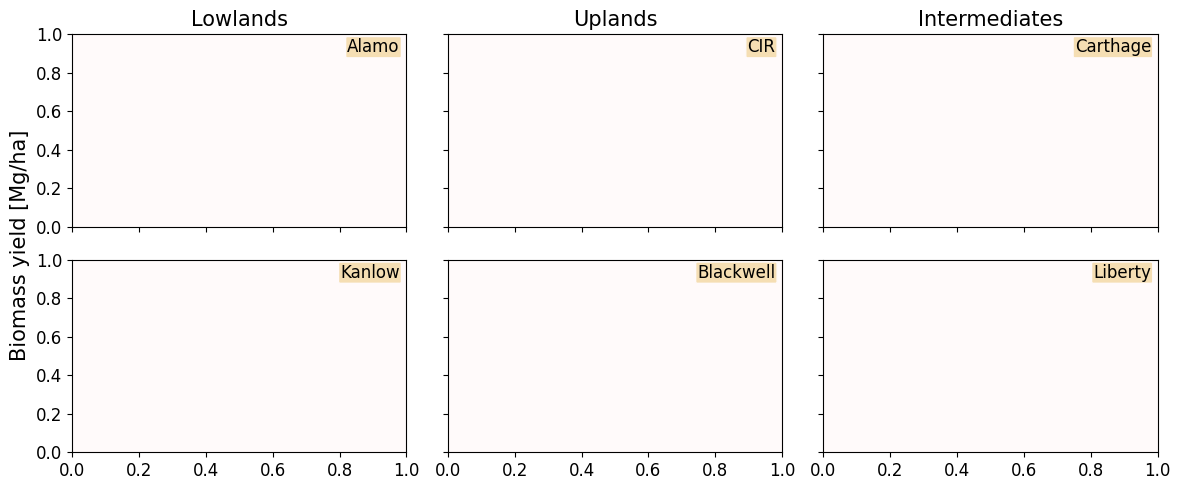

In [8]:
# Run and comment
fs = 12
tts = ['Lowlands', 'Uplands', 'Intermediates']
genotypes = ['Alamo', 'CIR', 'Carthage', 'Kanlow', 'Blackwell', 'Liberty']

# Dictionary with properties for the bounding box used with ax[i].text
bbprops = {'boxstyle':'round', 'pad':0.1, 'ec':'snow', 'facecolor':'wheat', 'alpha':1}

fig, ax = plt.subplots(2, 3, figsize=(12, 5), sharex=True, sharey=True)
ax = np.atleast_1d(ax).ravel()

for i in range(3):
    ax[i].set_title(tts[i], fontsize=1.25*fs)

for i in range(len(genotypes)):
    ax[i].set_facecolor('snow')
    ax[i].tick_params(labelsize=fs)
    
    # The transform parameter makes the coordinates relative for `ax[i].text` ONLY
    # The left-right x-coordinates go from 0 to 1 (regardless of the actual x-axis values)
    # The bottom-top y-coordinates go from 0 to 1 (regardless of the actual y-axis values)
    # That way, 0.98, 0.98 are the coordinates of the top-right corner
    # ha and va (horizonatal and vertical alignment) define how the text will be anchored
    ax[i].text(0.98,0.98, genotypes[i], transform=ax[i].transAxes, ha='right', va='top', fontsize=fs, bbox=bbprops)
    

fig.supylabel('Biomass yield [Mg/ha]', fontsize=1.25*fs)

# Uncomment these lines to plot the legend
# Essentially we are only plotting the legend of the first plot (because it is the same legend for the rest)
# Otherwise, we would plot 6 times the same legend

#h,l = ax[0].get_legend_handles_labels()
#fig.legend(h,l, loc='center left', bbox_to_anchor=(1.0,0.5), frameon=True, fontsize=fs)

fig.tight_layout()

### Further reading

- You can read more about the `tranform` parameter in `.text()` here: https://matplotlib.org/stable/users/explain/artists/transforms_tutorial.html
- Read more about text alignment (`va` and `ha`) here: https://matplotlib.org/stable/gallery/text_labels_and_annotations/text_alignment.html

---

## Congratulations, you're done!

Submit this assignment by uploading it to the course Canvas web page.  Go to the "In-class assignments" folder, find the appropriate submission link, and upload it there.

See you next class!

&#169; Copyright 2026,  Division of Plant Science & Technology&mdash;University of Missouri